# Laboratorio L9 - L'albero di decisione

B.6 - Data science e Machine Learning: dai dati ai modelli

File necessario: `pinguini.csv`.

Dati: Palmer Penguins, Horst AM, Hill AP, Gorman KB (2020), licenza CC0, https://allisonhorst.github.io/palmerpenguins/

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def controlla(condizione, suggerimento="Non ancora: rileggere la consegna."):
    """Stampa un riscontro immediato sull'esercizio."""
    print("Corretto." if condizione else suggerimento)

pinguini = pd.read_csv("pinguini.csv").dropna(subset=["becco_lunghezza_mm", "pinna_lunghezza_mm", "massa_g"])
SPECIE = ["Adelie", "Chinstrap", "Gentoo"]
COLORI = {"Adelie": "#2a78d6", "Chinstrap": "#eb6834", "Gentoo": "#1baf7a"}
CHIARI = ["#cfe0f5", "#fad6c6", "#c4ecdd"]
MARCATORI = {"Adelie": "o", "Chinstrap": "s", "Gentoo": "^"}
print(len(pinguini), "pinguini con tutte le misure")

342 pinguini con tutte le misure


## 1. Impurità di Gini (esercizio 1)

Impurità di Gini di un gruppo: 1 - (somma dei quadrati delle frazioni di ciascuna classe). Vale 0 se il gruppo contiene una sola classe; cresce quanto più le classi sono mescolate.

Esempio da verificare a mano: 10 pinguini, 4 Adelie, 3 Chinstrap, 3 Gentoo.

In [2]:
def gini(conteggi):
    totale = sum(conteggi)
    return 1 - sum((c / totale) ** 2 for c in conteggi)

print("gruppo iniziale:", round(gini([4, 3, 3]), 3))

gruppo iniziale: 0.66


Due divisioni candidate:

- divisione A, pinna > 206: a sinistra (pinna <= 206) 4 Adelie, 3 Chinstrap, 0 Gentoo; a destra 0, 0, 3
- divisione B, becco > 43: a sinistra 4 Adelie, 0, 0; a destra 0, 3 Chinstrap, 3 Gentoo

L'impurità di una divisione è la media delle impurità dei due gruppi, pesata con il numero di pinguini di ciascun gruppo.

Completare il calcolo per la divisione B.

In [3]:
div_A = 7 / 10 * gini([4, 3, 0]) + 3 / 10 * gini([0, 0, 3])
div_B = 4 / 10 * gini([4, 0, 0]) + 6 / 10 * gini([0, 3, 3])
print("divisione A:", round(div_A, 3))
print("divisione B:", round(div_B, 3))
controlla(round(div_B, 3) == 0.3, "A sinistra 4 Adelie e nessun altro; a destra 3 Chinstrap e 3 Gentoo.")

divisione A: 0.343
divisione B: 0.3
Corretto.


**Domanda**: quale divisione sceglierebbe l'algoritmo? Perché?

Risposta:

## 2. Addestrare un albero (esercizio 2)

- `DecisionTreeClassifier(max_depth=2)`: albero con al massimo due livelli di domande; `random_state=0` rende il risultato ripetibile
- `export_text`: l'albero come testo, con le soglie scelte

In [4]:
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree

X = pinguini[["becco_lunghezza_mm", "pinna_lunghezza_mm"]]
y = pinguini["specie"]
albero = DecisionTreeClassifier(max_depth=2, random_state=0)
albero.fit(X, y)
print(export_text(albero, feature_names=list(X.columns)))
print("accuratezza sui dati di addestramento:", round(albero.score(X, y), 3))

|--- pinna_lunghezza_mm <= 206.50
|   |--- becco_lunghezza_mm <= 43.35
|   |   |--- class: Adelie
|   |--- becco_lunghezza_mm >  43.35
|   |   |--- class: Chinstrap
|--- pinna_lunghezza_mm >  206.50
|   |--- becco_lunghezza_mm <= 40.85
|   |   |--- class: Adelie
|   |--- becco_lunghezza_mm >  40.85
|   |   |--- class: Gentoo

accuratezza sui dati di addestramento: 0.953


`plot_tree` disegna l'albero. In ogni nodo:

- la domanda (per esempio `pinna_lunghezza_mm <= 206.5`); a sinistra si va se la risposta è vera (True), a destra se è falsa
- `gini`: impurità del gruppo
- `samples`: numero di pinguini nel nodo
- `value`: quanti pinguini di ciascuna specie, in ordine alfabetico (Adelie, Chinstrap, Gentoo)
- `class`: la specie più frequente, cioè la previsione se ci si fermasse lì

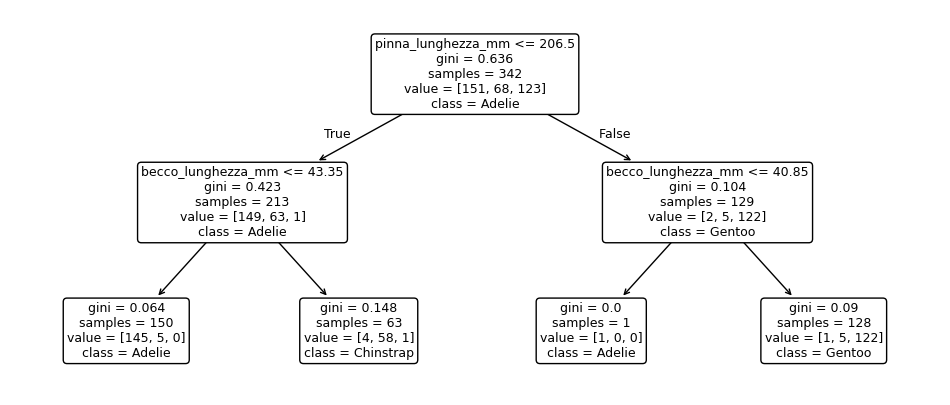

In [5]:
plt.figure(figsize=(12, 5))
plot_tree(albero, feature_names=list(X.columns), class_names=list(albero.classes_), rounded=True, fontsize=9)
plt.show()

**Domande**

- Confrontare le soglie dell'albero con le regole scritte in L7. Sono simili?
- Seguire il percorso di un pinguino con becco 45 mm e pinna 195 mm: quale specie riceve?

Risposte:

In [6]:
nuovo = pd.DataFrame({"becco_lunghezza_mm": [45.0], "pinna_lunghezza_mm": [195]})
albero.predict(nuovo)

array(['Chinstrap'], dtype=object)

## 3. Profondità dell'albero e confine di decisione (esercizio 3)

In [7]:
from matplotlib.colors import ListedColormap

def disegna_confine(prevedi, X, y, titolo=""):
    """Colora ogni punto del piano con la specie prevista e disegna sopra i pinguini veri.
    prevedi: funzione che riceve una tabella di punti (due colonne) e restituisce le specie previste."""
    a, b = X.iloc[:, 0], X.iloc[:, 1]
    ga, gb = np.meshgrid(np.linspace(a.min() - 1, a.max() + 1, 250),
                         np.linspace(b.min() - 2, b.max() + 2, 250))
    griglia = np.c_[ga.ravel(), gb.ravel()]                     # 62500 punti del piano
    previsti = np.array(prevedi(griglia))
    indici = np.array([SPECIE.index(s) for s in previsti]).reshape(ga.shape)
    plt.contourf(ga, gb, indici, levels=[-0.5, 0.5, 1.5, 2.5], cmap=ListedColormap(CHIARI))
    for s in SPECIE:
        sel = (y == s).to_numpy()
        plt.scatter(a[sel], b[sel], color=COLORI[s], marker=MARCATORI[s], s=18,
                    edgecolor="white", linewidth=0.5, label=s)
    plt.xlabel(X.columns[0]); plt.ylabel(X.columns[1]); plt.title(titolo)
    plt.legend(loc="lower right")
    plt.show()

profondità massima 1: profondità effettiva 1, foglie 2, accuratezza 0.792


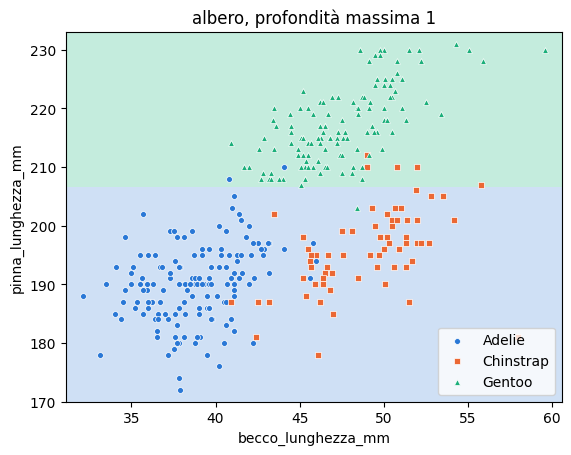

profondità massima 2: profondità effettiva 2, foglie 4, accuratezza 0.953


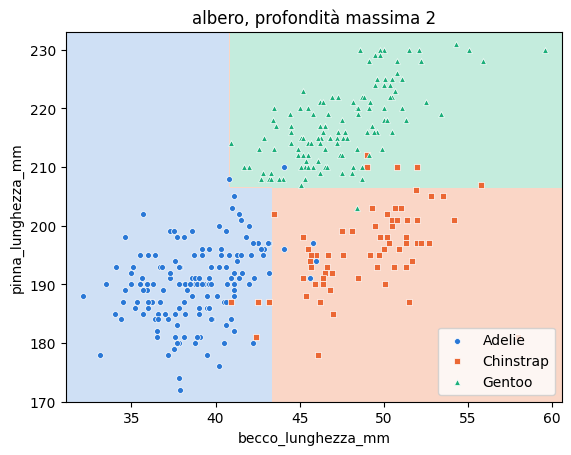

profondità massima 3: profondità effettiva 3, foglie 7, accuratezza 0.953


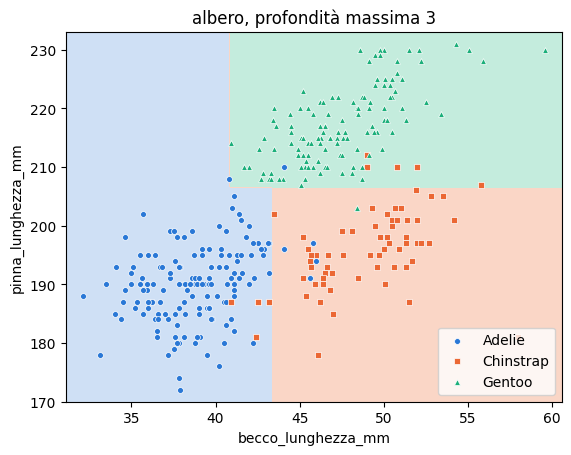

profondità massima None: profondità effettiva 7, foglie 27, accuratezza 1.000


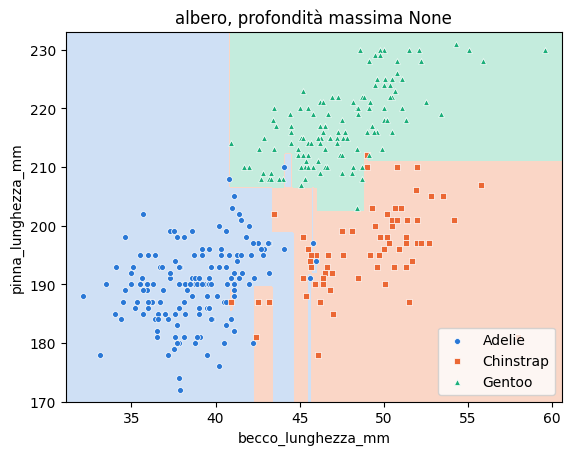

In [8]:
for profondita in [1, 2, 3, None]:
    a = DecisionTreeClassifier(max_depth=profondita, random_state=0).fit(X.values, y)
    print(f"profondità massima {profondita}: profondità effettiva {a.get_depth()}, foglie {a.get_n_leaves()}, accuratezza {a.score(X.values, y):.3f}")
    disegna_confine(a.predict, X, y, f"albero, profondità massima {profondita}")

**Domande**

- Con profondità 1 una specie non viene mai prevista. Perché?
- Senza limite di profondità l'accuratezza sui dati di addestramento è 1. Guardare il confine: è credibile per pinguini nuovi? (Tema di L11.)

Risposte:

## 4. Quattro misure e importanza delle caratteristiche (esercizio 4)

`feature_importances_`: quanto ciascuna caratteristica contribuisce a ridurre l'impurità nell'albero; la somma è 1.

In [9]:
misure = ["becco_lunghezza_mm", "becco_profondita_mm", "pinna_lunghezza_mm", "massa_g"]
albero4 = DecisionTreeClassifier(max_depth=3, random_state=0).fit(pinguini[misure], y)
print(export_text(albero4, feature_names=misure))
importanza = pd.Series(albero4.feature_importances_, index=misure).sort_values(ascending=False)
print(importanza.round(3))
controlla(importanza.index[0] in misure)

|--- pinna_lunghezza_mm <= 206.50
|   |--- becco_lunghezza_mm <= 43.35
|   |   |--- becco_lunghezza_mm <= 42.35
|   |   |   |--- class: Adelie
|   |   |--- becco_lunghezza_mm >  42.35
|   |   |   |--- class: Adelie
|   |--- becco_lunghezza_mm >  43.35
|   |   |--- massa_g <= 4125.00
|   |   |   |--- class: Chinstrap
|   |   |--- massa_g >  4125.00
|   |   |   |--- class: Chinstrap
|--- pinna_lunghezza_mm >  206.50
|   |--- becco_profondita_mm <= 17.65
|   |   |--- class: Gentoo
|   |--- becco_profondita_mm >  17.65
|   |   |--- becco_profondita_mm <= 18.95
|   |   |   |--- class: Adelie
|   |   |--- becco_profondita_mm >  18.95
|   |   |   |--- class: Chinstrap

pinna_lunghezza_mm     0.559
becco_lunghezza_mm     0.361
becco_profondita_mm    0.066
massa_g                0.014
dtype: float64
Corretto.


**Domanda**: quali caratteristiche usa l'albero? Quali non usa? Confrontare con le osservazioni sui grafici di L6.

Risposta:

## 5. Approfondimento (esercizio 5)

Il parametro `min_samples_leaf` impone un numero minimo di pinguini in ogni foglia. Provare 1, 5, 20 con profondità illimitata e osservare numero di foglie, accuratezza e confine.

In [10]:
for minimo in [1, 5, 20]:
    a = DecisionTreeClassifier(min_samples_leaf=minimo, random_state=0).fit(X.values, y)
    print(f"min_samples_leaf {minimo:2}: foglie {a.get_n_leaves():2}, accuratezza {a.score(X.values, y):.3f}")

min_samples_leaf  1: foglie 27, accuratezza 1.000
min_samples_leaf  5: foglie 14, accuratezza 0.971
min_samples_leaf 20: foglie  8, accuratezza 0.950
